# Fine-tuning DTrOCR on IAM dataset
This is an example of fine-tuning DTrOCR on IAM dataset handwritten words from [Kaggle](https://www.kaggle.com/datasets/teykaicong/iamondb-handwriting-dataset). IAM Aachen splits can be downloaded [here](https://www.openslr.org/56/).

# Dataset folder structure
```
K49/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels/                                # txt files
	├── 0.txt
	.
	.
	.
	└── 1.txt
```

# Build lists of images and texts

Number of training samples: 232365
Number of testing samples: 38547


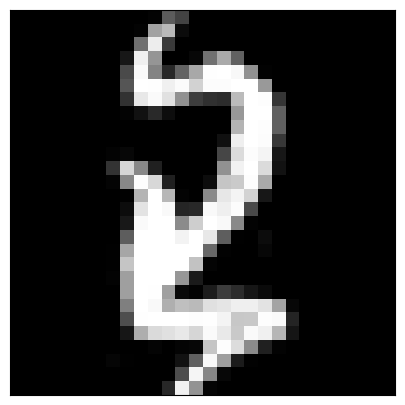

In [1]:
import deeplake
import numpy as np
from torch.utils.data import random_split
from PIL import Image
import matplotlib.pyplot as plt
test_imgs = np.load('../kmnist/k49-test-imgs.npz')['arr_0']
test_labels = np.load('../kmnist/k49-test-labels.npz')['arr_0']
train_imgs = np.load('../kmnist/k49-train-imgs.npz')['arr_0']
train_labels = np.load('../kmnist/k49-train-labels.npz')['arr_0']
print("Number of training samples:", len(train_imgs))
print("Number of testing samples:", len(test_imgs))
image = Image.fromarray(train_imgs[9]).convert('RGB')
plt.figure(figsize=(10, 5))
plt.imshow(np.array(image, dtype=np.uint8))
plt.xticks([]), plt.yticks([])
plt.show()

In [2]:
import csv

with open('../kmnist/k49_classmap.csv', mode='r') as table:
    reader = csv.reader(table)
    class_to_transcription = dict((rows[0], rows[2]) for rows in reader)
        
print(class_to_transcription['0'])
labels = list()
for label in train_labels:
    labels.append(class_to_transcription[str(label)])
    
print(train_labels[0], labels[0])

for label in test_labels:
    labels.append(class_to_transcription[str(label)])
    
print(labels[65000])

あ
30 ま
に


In [3]:
from pathlib import Path

Path('data/K49').mkdir(parents=True, exist_ok=True)
Path('data/K49/images').mkdir(parents=True, exist_ok=True)
Path('data/K49/labels').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)

# Create images and labels from numpy arrays

In [4]:
ind = 0
for image in train_imgs:
    savepath = 'data/K49/' + 'images/' + str(ind) + '.png'
    Image.fromarray(image).save(savepath)
    ind += 1
    
for image in test_imgs:
    savepath = 'data/K49/' + 'images/' + str(ind) + '.png'
    Image.fromarray(image).save(savepath)
    ind += 1
    
ind = 0
for label in labels:
    savepath = 'data/K49/' + 'labels/' + str(ind) + '.txt'
    with open(savepath, 'w') as file:
        file.write(label)
    ind += 1
    

# Build lists of images and texts

In [5]:
import glob
from pathlib import Path

dataset_path = Path('data/K49')

txt_files = sorted(glob.glob(str(dataset_path / 'labels' / '*.txt')))
word_image_files = sorted(glob.glob(str(dataset_path / 'images' / '**' / '*.png'), recursive=True))

print(f"{len(txt_files)} txt files and {len(word_image_files)} word image files")

words_files = [list(x) for x in zip(txt_files, word_image_files)]
print(words_files[0])


270912 txt files and 270912 word image files
['data/K49/labels/0.txt', 'data/K49/images/0.png']


In [6]:
import tqdm
import multiprocessing as mp
import xml.etree.ElementTree as ET
import functools
from PIL import Image
from dataclasses import dataclass


@dataclass
class Word:
    file_path: Path
    transcription: str
    

def get_word(word_file):
    words = []
    with open(word_file[0], 'r') as file:
        words.append(
            Word(
                file_path=word_file[1],
                transcription=file.read()
            )
        )
    return words


with mp.Pool(processes=mp.cpu_count()) as pool:
    words = list(
        tqdm.tqdm(
            pool.imap(get_word, words_files), 
            total=len(words_files),
            desc='Building dataset'
        )
    )
    
words = [word for words in words for word in words]

Building dataset: 100%|██████████| 270912/270912 [01:04<00:00, 4177.78it/s] 


# Train test split

In [7]:
train_word_records, validation_word_records, test_word_records = np.split(words, [int(len(words)*0.8), int(len(words)*0.9)])
print(f'Train size: {len(train_word_records)}; Validation size: {len(validation_word_records)}; Test size: {len(test_word_records)}')

Train size: 55000; Validation size: 5000; Test size: 10001
ま data/K49/images/149497.png data/K49/images/149498.png data/K49/images/153997.png data/K49/images/153998.png data/K49/images/162997.png


# Build dataset and dataloader

In [8]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig
from pathlib import Path

from torch.utils.data import Dataset
    
class IAMDataset(Dataset):
    def __init__(self, words: list[Word], config: DTrOCRConfig):
        super(IAMDataset, self).__init__()
        self.words = words
        self.processor = DTrOCRProcessor(config, add_eos_token=True, add_bos_token=True)
        
    def __len__(self):
        return len(self.words)
    
    def __getitem__(self, item):
        inputs = self.processor(
            images=Image.open(self.words[item].file_path).convert('RGB'),
            texts=self.words[item].transcription,
            padding='max_length',
            return_tensors="pt",
            return_labels=True,
        )
        return {
            'pixel_values': inputs.pixel_values[0],
            'input_ids': inputs.input_ids[0],
            'attention_mask': inputs.attention_mask[0],
            'labels': inputs.labels[0]
        }

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)

train_data = IAMDataset(words=train_word_records, config=config)
validation_data = IAMDataset(words=validation_word_records, config=config)
test_data = IAMDataset(words=test_word_records, config=config)

/home/kane/miniconda3/envs/JDict/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from torch.utils.data import DataLoader
import multiprocessing as mp

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
validation_dataloader = DataLoader(validation_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())

# Model

In [10]:
import torch
torch.set_float32_matmul_precision('high')

from dtrocr.model import DTrOCRLMHeadModel

model = DTrOCRLMHeadModel(config)
model = torch.compile(model)
model.to(device=0)

OptimizedModule(
  (_orig_mod): DTrOCRLMHeadModel(
    (transformer): DTrOCRModel(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(4, 8), stride=(4, 8))
      )
      (token_embedding): Embedding(50257, 768)
      (positional_embedding): Embedding(256, 768)
      (hidden_layers): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2SdpaAttention(
            (c_attn): Conv1D(nf=2304, nx=768)
            (c_proj): Conv1D(nf=768, nx=768)
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D(nf=3072, nx=768)
            (c_proj): Conv1D(nf=768, nx=3072)
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
      

# Training

In [11]:
from typing import Tuple
import tqdm

def evaluate_model(model: torch.nn.Module, dataloader: DataLoader) -> Tuple[float, float]:
    # set model to evaluation mode
    model.eval()
    
    losses, accuracies = [], []
    with torch.no_grad():
        for inputs in tqdm.tqdm(dataloader, total=len(dataloader), desc=f'Evaluating test set'):
            inputs = send_inputs_to_device(inputs, device=0)
            outputs = model(**inputs)
            
            losses.append(outputs.loss.item())
            accuracies.append(outputs.accuracy.item())
    
    loss = sum(losses) / len(losses)
    accuracy = sum(accuracies) / len(accuracies)
    
    # set model back to training mode
    model.train()
    
    return loss, accuracy

def send_inputs_to_device(dictionary, device):
    return {key: value.to(device=device) if isinstance(value, torch.Tensor) else value for key, value in dictionary.items()}

use_amp = True
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
optimiser = torch.optim.Adam(params=model.parameters(), lr=1e-4)

EPOCHS = 1
train_losses, train_accuracies = [], []
validation_losses, validation_accuracies = [], []
test_losses, test_accuracies = [], []
for epoch in range(EPOCHS):
    epoch_losses, epoch_accuracies = [], []
    for inputs in tqdm.tqdm(train_dataloader, total=len(train_dataloader), desc=f'Epoch {epoch + 1}'):
        
        # set gradients to zero
        optimiser.zero_grad()
        
        # send inputs to same device as model
        inputs = send_inputs_to_device(inputs, device=0)
        
        # forward pass
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
            outputs = model(**inputs)
        
        # calculate gradients
        scaler.scale(outputs.loss).backward()
        
        # update weights
        scaler.step(optimiser)
        scaler.update()
        
        epoch_losses.append(outputs.loss.item())
        epoch_accuracies.append(outputs.accuracy.item())
        
    # store loss and metrics
    train_losses.append(sum(epoch_losses) / len(epoch_losses))
    train_accuracies.append(sum(epoch_accuracies) / len(epoch_accuracies))
    
    # tests loss and accuracy
    validation_loss, validation_accuracy = evaluate_model(model, validation_dataloader)
    validation_losses.append(validation_loss)
    validation_accuracies.append(validation_accuracy)
    
    test_loss, test_accuracy = evaluate_model(model, validation_dataloader)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
                    
    print(f"Epoch: {epoch + 1} - Train loss: {train_losses[-1]}, Train accuracy: {train_accuracies[-1]}, Validation loss: {validation_losses[-1]}, Validation accuracy: {validation_accuracies[-1]}, Test loss: {test_losses[-1]}, Test accuracy: {test_accuracies[-1]}")

Evaluating test set: 100%|██████████| 157/157 [01:33<00:00,  1.67it/s]

Epoch: 1 - Train loss: 1.0252056985035964, Train accuracy: 0.7582538599140808, Validation loss: 0.36522251585866233, Validation accuracy: 0.8913037139139358, Test loss: 0.36522251585866233, Test accuracy: 0.8913037139139358


# Test

In [12]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
torch.save(model.state_dict(), '../models/K-49_test.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

In [13]:
import matplotlib

matplotlib.rc('font', family='TakaoPGothic')

こ


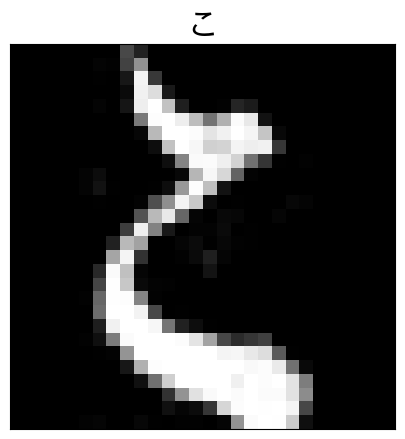

お


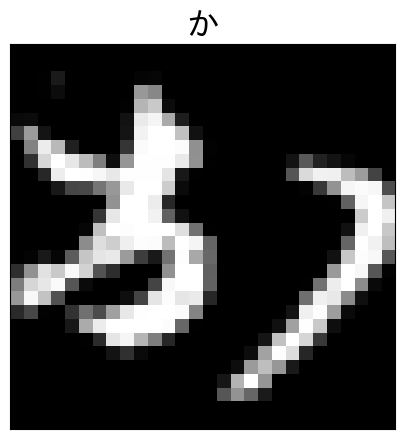

い


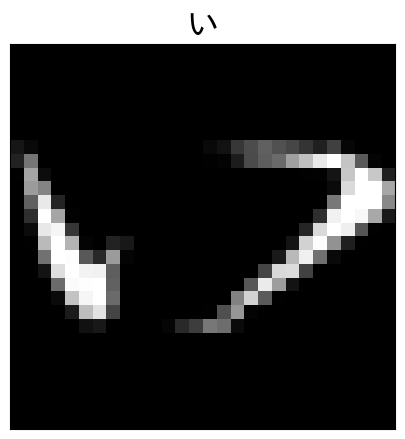

て


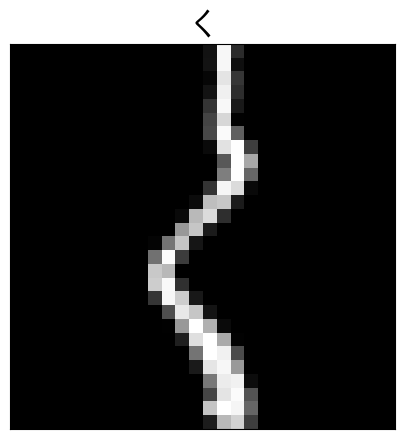

み


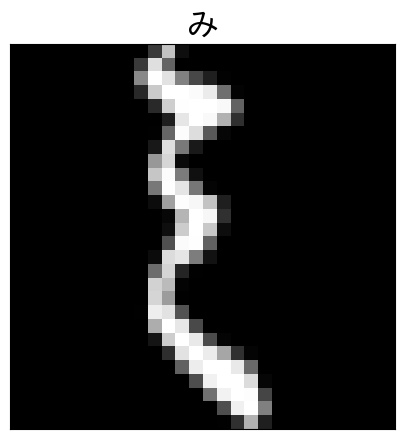

た


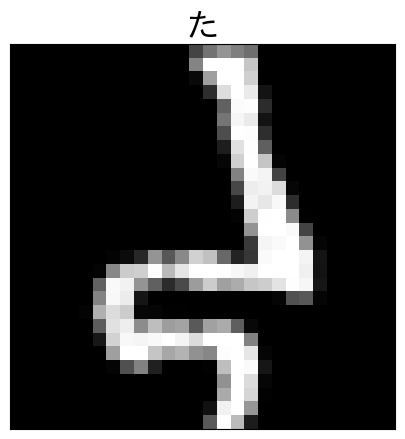

な


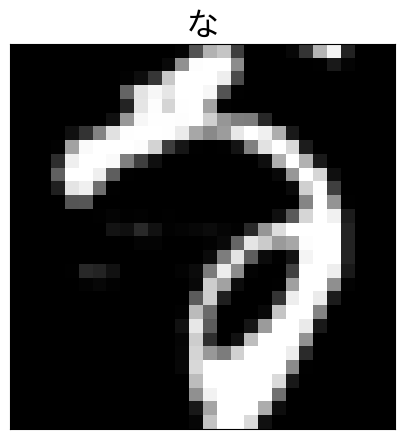

も


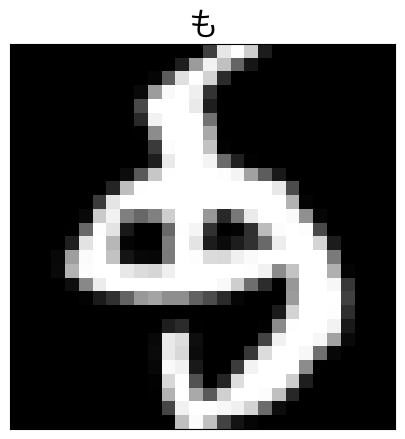

か


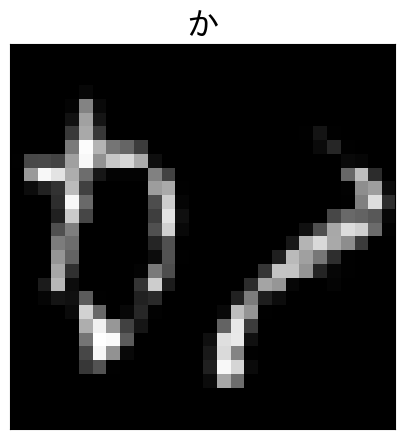

わ


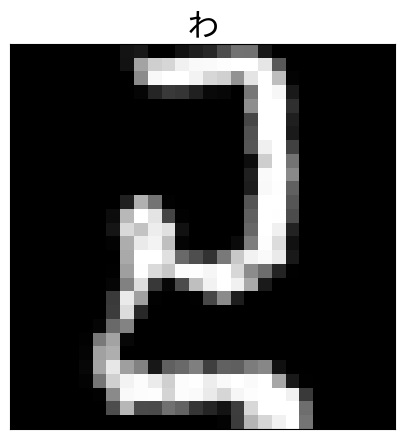

In [14]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

for test_word_record in test_word_records[:10]:
    image_file = test_word_record.file_path
    image = Image.open(image_file).convert('RGB')
    
    inputs = test_processor(
        images=image, 
        texts=test_processor.tokeniser.bos_token,
        return_tensors='pt'
    )
    
    model_output = model.generate(
        inputs, 
        test_processor,
        num_beams=3
    )
    print(test_word_record.transcription)
    
    predicted_text = test_processor.tokeniser.decode(model_output[0], skip_special_tokens=True)
    
    plt.figure(figsize=(10, 5))
    plt.title(predicted_text, fontsize=24)
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()
    torch.save(model.state_dict(), '../models/K-49_test.pt')